In [1]:
import json
import os
import sqlite3
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from dotenv import load_dotenv


In [2]:
def query_results(query: str, path2db: Path, parameters: tuple | None) -> list[Any]:
    if parameters is None:
        parameters = tuple()
    conn = sqlite3.connect(path2db)
    rows = conn.execute(query, parameters).fetchall()
    conn.close()
    return rows

In [3]:
start_date = "2026-07-20 00:00:00"
end_date = "2026-08-17 23:59:59"
query = """
    SELECT countryCode, COUNT(*) AS count
    FROM logs
    WHERE Agent_Type = 'H'
    AND strftime('%Y-%m-%d %H:%M:%S', datetime) BETWEEN ? AND ?
    GROUP BY countryCode
    ORDER BY count DESC
    """

In [4]:
# Get the paths
if (str(Path.cwd()) == '/app'):
    data_dir = Path('/app/data.philiplessner.com')
else:
    load_dotenv()
    data_dir = Path(os.environ['DATA_FILE_DIR'])
path2db = Path(data_dir, 'logs.db')

In [5]:
country_counts = query_results(query, path2db, (start_date, end_date))

In [6]:
countryCodes = [countryCode for countryCode, count in country_counts]
counts = [count for countryCode, count in country_counts]

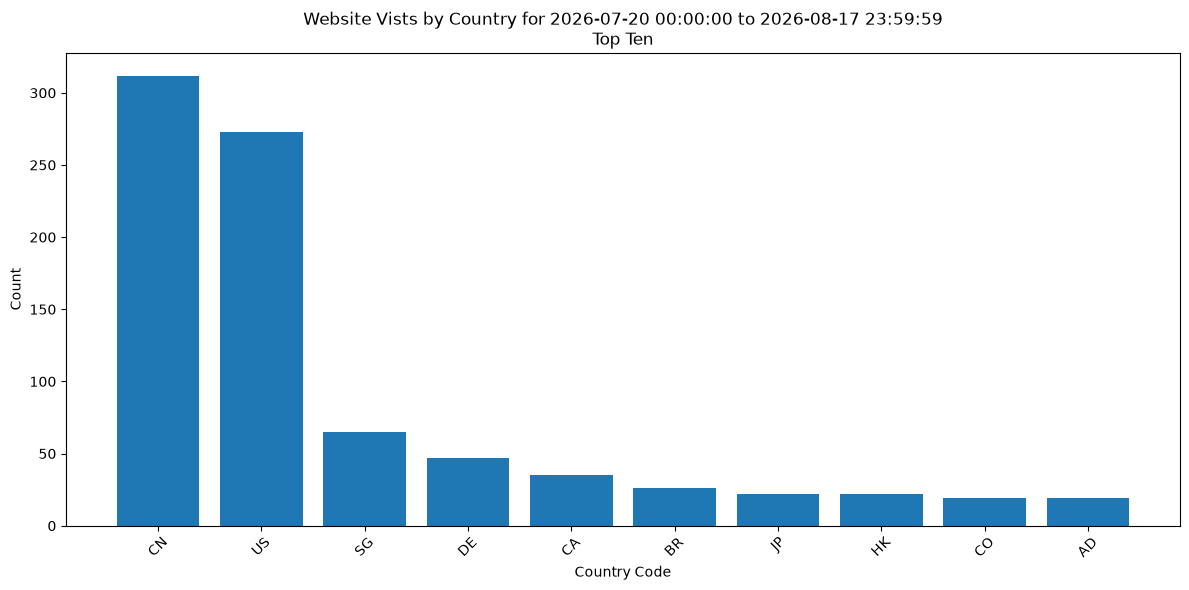

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(countryCodes[:10], counts[:10])
plt.title(f'Website Vists by Country for {start_date} to {end_date}\nTop Ten')
plt.xlabel('Country Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

In [9]:

chart_html = f"""
<html>
<div>
  <canvas id="myChart"></canvas>
</div>

<script src="/media/phil/m2ssd/web/logs/data.philiplessner.com/chart.umd.min.js"></script>

<script>
  const ctx = document.getElementById('myChart');

  new Chart(ctx, {{
    type: 'bar',
    data: {{
      labels: {json.dumps(countryCodes[:10])},
      datasets: [{{
        label: 'Website Visits by Country for {json.dumps(start_date)} to {json.dumps(end_date)}',
        data: {json.dumps(counts[:10])},
        borderWidth: 1
      }}]
    }},
    options: {{
      scales: {{
        y: {{
          beginAtZero: true
        }}
      }}
    }}
  }});
</script>
</html>
"""

with open(Path(data_dir, 'countryCode_counts.html'), 'w', encoding='utf-8') as f:
    f.write(chart_html) 


In [10]:
start_date = "2026-07-20 00:00:00"
end_date = "2026-08-17 23:59:59"
endpoint_query = """
    SELECT endpoint, COUNT(*) AS count
    FROM logs
    WHERE Agent_Type = 'H'
    AND strftime('%Y-%m-%d %H:%M:%S', datetime) BETWEEN ? AND ?
    GROUP BY endpoint
    ORDER BY count DESC
    """

In [11]:

endpoint_counts = query_results(endpoint_query, path2db, (start_date, end_date))

In [12]:
endpoints = [endpoint for endpoint, _ in endpoint_counts]
counts = [count for _, count in endpoint_counts]

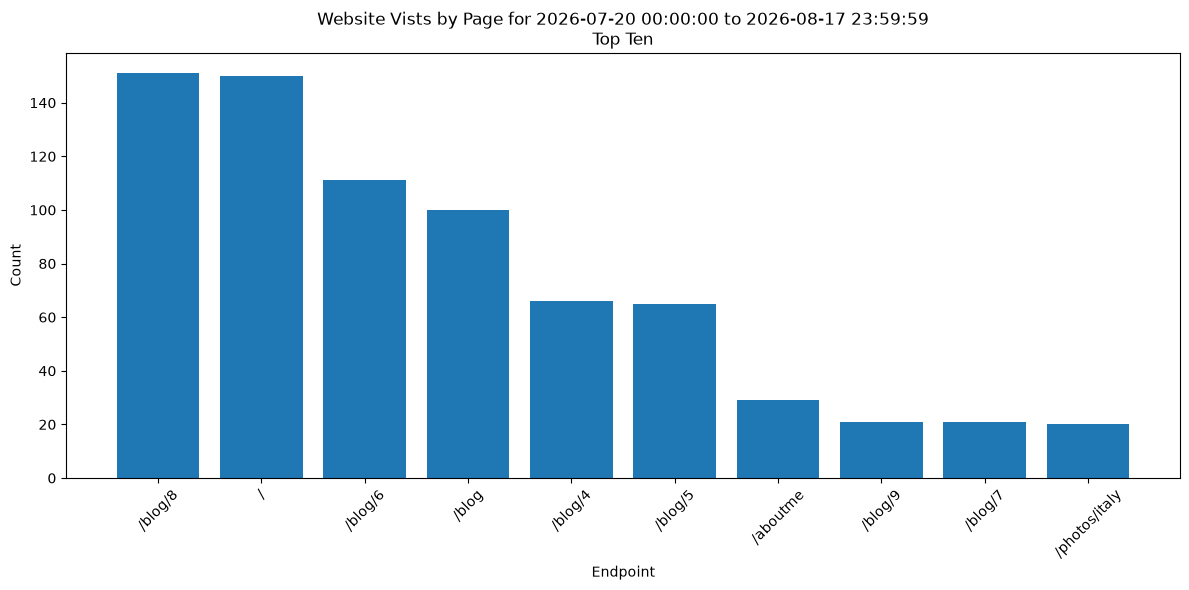

In [13]:

plt.figure(figsize=(12, 6))
plt.bar(endpoints[:10], counts[:10])
plt.title(f'Website Vists by Page for {start_date} to {end_date}\nTop Ten')
plt.xlabel('Endpoint')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

In [15]:

endpoint_html = f"""
<html>
<div>
  <canvas id="myChart"></canvas>
</div>

<script src="/media/phil/m2ssd/web/logs/data.philiplessner.com/chart.umd.min.js"></script>

<script>
  const ctx = document.getElementById('myChart');

  new Chart(ctx, {{
    type: 'bar',
    data: {{
      labels: {json.dumps(endpoints[:10])},
      datasets: [{{
        label: 'Website Visits by Endpoint for {json.dumps(start_date)} to {json.dumps(end_date)}',
        data: {json.dumps(counts[:10])},
        borderWidth: 1
      }}]
    }},
    options: {{
      scales: {{
        y: {{
          beginAtZero: true
        }}
      }}
    }}
  }});
</script>
</html>
"""

with open(Path(data_dir, 'endpoint_counts.html'), 'w', encoding='utf-8') as f:
    f.write(endpoint_html) 


In [19]:
visits_query = """SELECT DATE(datetime) AS visit_day,
       COUNT(*) AS visit_count
FROM logs
WHERE strftime('%Y-%m-%d %H:%M:%S', datetime) BETWEEN ? AND ?
GROUP BY DATE(datetime)
ORDER BY visit_day;
"""

In [20]:

visits_counts = query_results(visits_query, path2db, (start_date, end_date))

In [21]:
visits_counts

[('2026-07-20', 73),
 ('2026-07-21', 60),
 ('2026-07-22', 71),
 ('2026-07-23', 57),
 ('2026-07-24', 78),
 ('2026-07-25', 113),
 ('2026-07-26', 86),
 ('2026-07-27', 85),
 ('2026-07-28', 60),
 ('2026-07-29', 45),
 ('2026-07-30', 64),
 ('2026-07-31', 121),
 ('2026-08-01', 89),
 ('2026-08-02', 139),
 ('2026-08-03', 72),
 ('2026-08-04', 62),
 ('2026-08-05', 84),
 ('2026-08-06', 68),
 ('2026-08-07', 161),
 ('2026-08-08', 107),
 ('2026-08-09', 101),
 ('2026-08-10', 74),
 ('2026-08-11', 77),
 ('2026-08-12', 154),
 ('2026-08-13', 55),
 ('2026-08-14', 159),
 ('2026-08-15', 121),
 ('2026-08-16', 78),
 ('2026-08-17', 85)]